In [1]:
!gdown --id 1bFx6uiQV-GUGwL3PwYRIYdmRCF9hS2bP

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1bFx6uiQV-GUGwL3PwYRIYdmRCF9hS2bP
From (redirected): https://drive.google.com/uc?id=1bFx6uiQV-GUGwL3PwYRIYdmRCF9hS2bP&confirm=t&uuid=7bf26307-59f7-472a-8d15-6ca3001bd758
To: /kaggle/working/FER-2013.zip
100%|██████████████████████████████████████| 63.3M/63.3M [00:01<00:00, 39.4MB/s]


In [2]:
!unzip -q ./FER-2013.zip

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torchsummary import summary
import matplotlib.pyplot as plt
from PIL import Image



In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [6]:
train_dir = './train'
test_dir = './test'

In [7]:
os.listdir(train_dir)

['happy', 'angry', 'neutral', 'surprise', 'disgust', 'sad', 'fear']

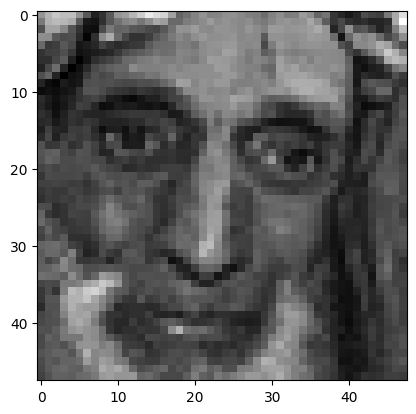

In [8]:
img = read_image("./train/sad/Training_10091569.jpg")
plt.imshow(img.squeeze(0), cmap='gray')

In [9]:
img.shape

torch.Size([1, 48, 48])

In [ ]:
train_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=1),
    v2.RandomResizedCrop(size=(48, 48), scale=(0.8, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=1),
    v2.ToDtype(torch.float32, scale=True),
])

In [12]:
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

Text(0.5, 1.0, 'Test')

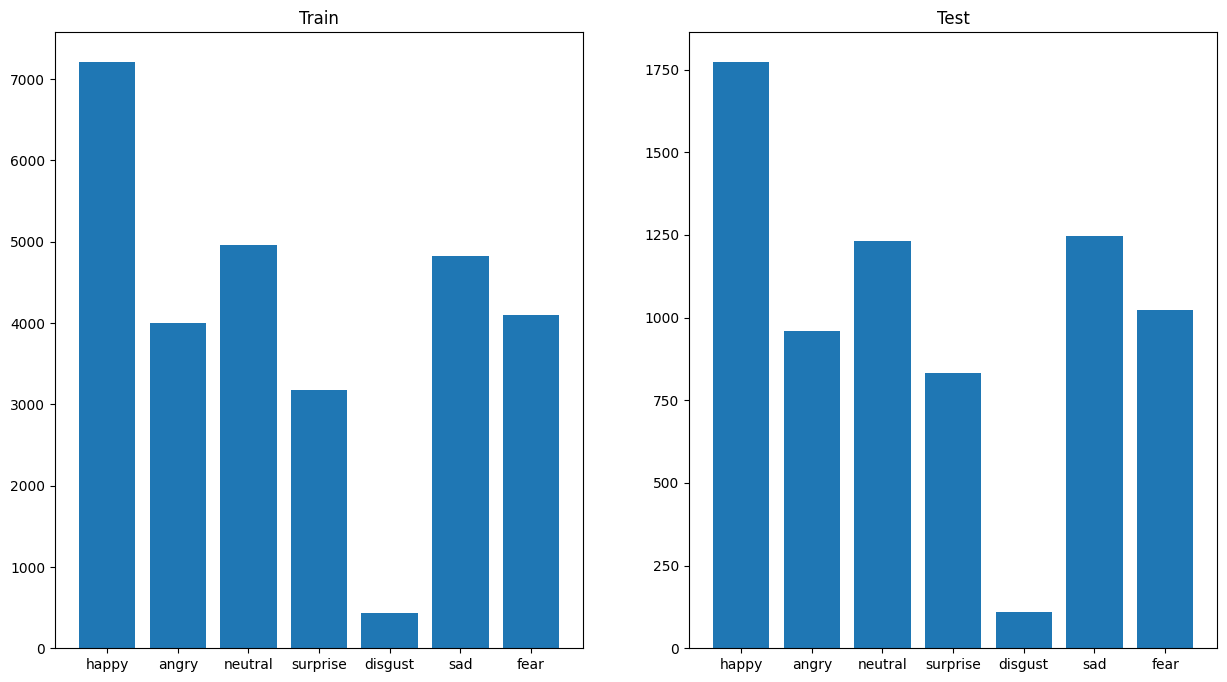

In [ ]:
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(1, 2, 1)
labels = os.listdir(train_dir)
train_count = [len(os.listdir(os.path.join(train_dir, label))) for label in os.listdir(train_dir)]
ax.bar(labels, train_count)
ax.set_title("Train")

ax = fig.add_subplot(1, 2, 2)
labels = os.listdir(test_dir)
test_count = [len(os.listdir(os.path.join(test_dir, label))) for label in os.listdir(test_dir)]
ax.bar(labels, test_count)
ax.set_title("Test")

In [14]:
train_data[0][0].shape

torch.Size([1, 48, 48])

In [ ]:
N = len(train_data)
BATCH_SIZE = 128
class_weights = torch.tensor([N/(2 * count) for count in train_count], dtype=torch.float32).to(device)


In [ ]:
train_loader = DataLoader(train_data,batch_size = BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data,batch_size = 256)


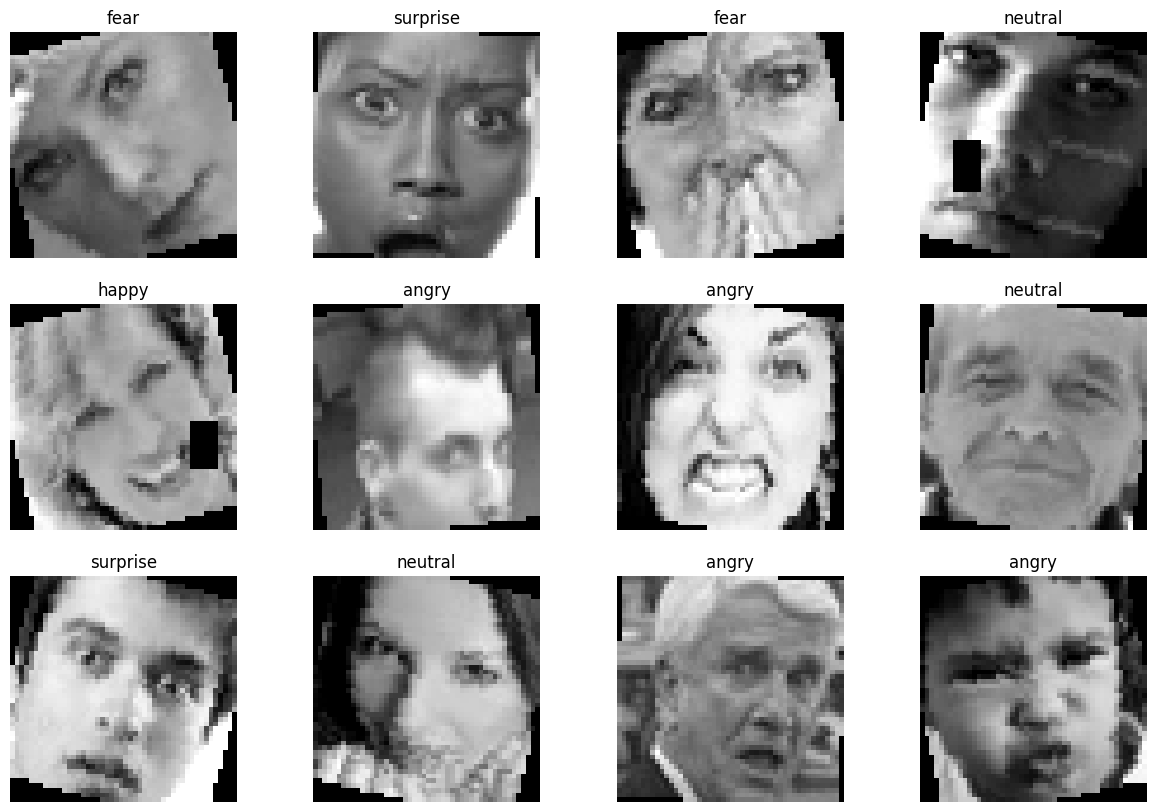

In [17]:
idx_to_class = {idx: class_name for class_name, idx in train_data.class_to_idx.items()}
imgs, labels = next(iter(train_loader))
fig = plt.figure(figsize=(15, 10))

for i in range(12):
  ax = fig.add_subplot(3, 4, i+1)
  ax.imshow(imgs[i].permute(1, 2, 0), cmap='gray')
  ax.set_title(idx_to_class[labels[i].item()])
  ax.axis('off')

In [18]:
len(train_loader)

225

In [ ]:
class VGG8(nn.Module):
    def __init__(self, num_classes=7):
        super(VGG8, self).__init__()

        self.features = nn.Sequential(
            # Block 1: (1, 48, 48) -> (64, 24, 24)
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2:  (64, 24, 24) -> (128, 12, 12)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: (128, 12, 12) -> (256, 6, 6)
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: (256, 6, 6) -> (512, 3, 3)
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=5, padding=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.2),


            # Block 5: (512, 3, 3) -> (512, 1, 1)
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=5, padding=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.2) ,
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # FC 1
            nn.Linear(in_features=512 * 1 * 1, out_features=512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),

            # FC 2
            nn.Linear(in_features=512, out_features=256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),

            # FC 3 (Output Layer)
            nn.Linear(in_features=256, out_features=num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [22]:
model = VGG8().to(device)

In [23]:
summary(model, (1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]           1,664
       BatchNorm2d-2           [-1, 64, 48, 48]             128
              ReLU-3           [-1, 64, 48, 48]               0
         MaxPool2d-4           [-1, 64, 24, 24]               0
            Conv2d-5          [-1, 128, 24, 24]         204,928
       BatchNorm2d-6          [-1, 128, 24, 24]             256
              ReLU-7          [-1, 128, 24, 24]               0
         MaxPool2d-8          [-1, 128, 12, 12]               0
            Conv2d-9          [-1, 256, 12, 12]         819,456
      BatchNorm2d-10          [-1, 256, 12, 12]             512
             ReLU-11          [-1, 256, 12, 12]               0
        MaxPool2d-12            [-1, 256, 6, 6]               0
           Conv2d-13            [-1, 512, 6, 6]       3,277,312
      BatchNorm2d-14            [-1, 51

In [24]:
next(model.parameters()).is_cuda


True

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=3.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        
        pt = torch.exp(-ce_loss)
        
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [26]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = FocalLoss(alpha = class_weights, gamma = 3.0 ,reduction ="mean")

In [27]:
import time

def train(model, optimizer, criterion, train_dataloader, device, log_interval=50):
    model.train()
    total_acc, total_count = 0, 0
    losses = []
    start_time = time.time()

    for idx, (inputs, labels) in enumerate(train_dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predictions = model(inputs)

        # compute loss
        loss = criterion(predictions, labels)
        losses.append(loss.item())

        # backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        total_acc += (predictions.argmax(1) == labels).sum().item()
        total_count += len(labels)

    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss

In [28]:
def evaluate(model, criterion, valid_dataloader):
    model.eval()
    total_acc, total_count = 0, 0
    losses = []

    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(valid_dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            predictions = model(inputs)

            loss = criterion(predictions, labels)
            losses.append(loss.item())

            total_acc += (predictions.argmax(1) == labels).sum().item()
            total_count += len(labels)

    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss

In [29]:
train_accs, train_losses = [], []
eval_accs, eval_losses = [], []
best_loss_eval = 100

def model_training(epochs):
  for epoch in range(1, epochs+1):
      epoch_start_time = time.time()
      # Training
      train_acc, train_loss = train_acc, train_loss = train(model, optimizer, criterion, train_loader, device)
      train_accs.append(train_acc)
      train_losses.append(train_loss)

      # Evaluation
      eval_acc, eval_loss = eval_acc, eval_loss = evaluate(model, criterion, test_loader)
      eval_accs.append(eval_acc)
      eval_losses.append(eval_loss)

      print("-" * 59)
      print(
          "| End of epoch {:3d} | Time: {:5.2f}s | Train Accuracy {:8.3f} | Train Loss {:8.3f} "
          "| Valid Accuracy {:8.3f} | Valid Loss {:8.3f} ".format(
              epoch, time.time() - epoch_start_time, train_acc, train_loss, eval_acc, eval_loss
          )
      )
      print("-" * 59)

In [ ]:
model_training(80)

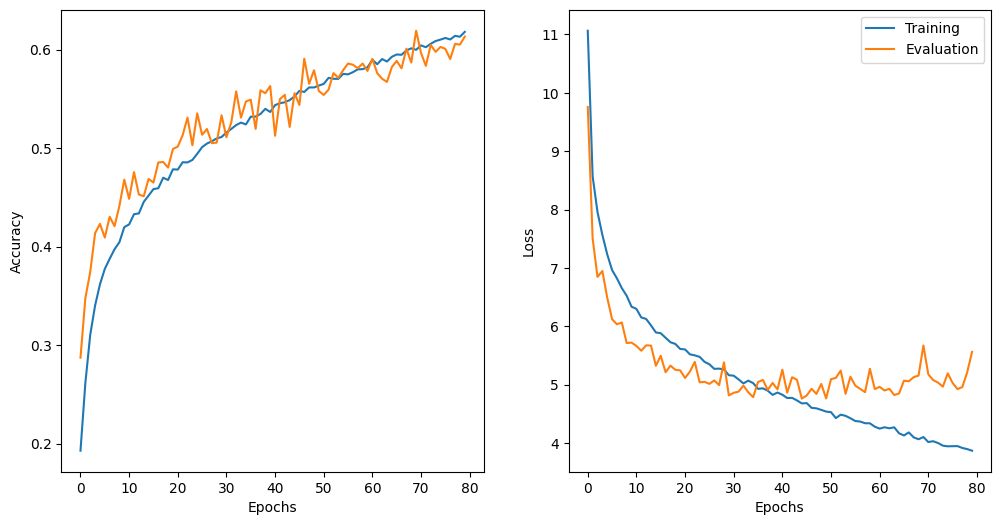

In [37]:
def plot_result(num_epochs, train_accs, eval_accs, train_losses, eval_losses):
    epochs = list(range(num_epochs))
    fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
    axs[0].plot(epochs, train_accs, label = "Training")
    axs[0].plot(epochs, eval_accs, label = "Evaluation")
    axs[1].plot(epochs, train_losses, label = "Training")
    axs[1].plot(epochs, eval_losses, label = "Evaluation")
    axs[0].set_xlabel("Epochs")
    axs[1].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[1].set_ylabel("Loss")
    plt.legend()

plot_result(len(train_accs), train_accs, eval_accs, train_losses, eval_losses)

In [ ]:
torch.save(model.state_dict(), "weights.pth")